In [10]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, accuracy_score, f1_score
from skopt import BayesSearchCV
from skopt.space import Real, Integer
import pickle
import joblib
import os

In [12]:
# Binary classifier
# data = combined, same as the regression model but with the binary label?
df_binary = pd.read_parquet("../0_data/processed_data/data_with_selected_features_LGB_All_scaled_binary.parquet")
df_binary = df_binary[df_binary['Type'] == 'Train'].reset_index(drop=True)

df_binary

,SMILES,MP,Type,MP_label,RDKit_FpDensityMorgan3,RDKit_TPSA,RDKit_NumRotatableBonds,RDKit_SMR_VSA10,RDKit_BCUT2D_LOGPHI,RDKit_BCUT2D_MRLOW,...,RDKit_Chi2n,RDKit_SlogP_VSA3,RDKit_fr_Ar_NH,RDKit_EState_VSA4,MACCS_89,RDKit_SMR_VSA9,MACCS_131,RDKit_fr_imidazole,RDKit_Chi0,Binary
0,COc1ccc(cc1)C1(C)CCc2c(-c3c1cc(o3)C)c1c(o2)ccc...,170.00,Train,L,0.521953,-0.457762,-0.257788,-0.426305,1.304807,0.417798,...,1.616871,0.778243,-0.20324,3.472367,2.047792,2.116818,-0.562084,-0.133569,1.335854,0
1,C[C@H]1[C@@H]2CC[C@@H]3[C@](C1=O)(C2)C(=O)OC[C...,296.85,Train,H,0.790196,0.502246,-0.865765,0.037682,2.292861,-0.759300,...,2.229837,2.356382,-0.20324,1.776268,2.047792,-0.586923,-0.562084,-0.133569,0.986054,1
2,Cc1cc(Br)c(cc1Br)C,73.00,Train,L,-1.394071,-1.455709,-0.865765,1.009138,-0.015188,2.162965,...,-0.692189,-0.775518,-0.20324,-0.906021,-0.488331,-0.586923,-0.562084,-0.133569,-0.880351,0
3,OC(=O)c1ccc(c(c1)F)C,170.00,Train,L,0.783228,-0.407457,-0.561777,-0.769862,-0.827313,-0.231414,...,-0.725133,-0.775518,-0.20324,-0.399178,-0.488331,-0.586923,-0.562084,-0.133569,-0.746893,0
4,OC(=O)C1CC(=O)c2c1cccc2,116.00,Train,L,1.037805,0.072266,-0.561777,-0.372483,0.412897,-0.623661,...,-0.386943,-0.146109,-0.20324,-0.906021,-0.488331,-0.586923,-0.562084,-0.133569,-0.559748,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12049,N#CCC(=O)c1ccc(c(c1)Cl)Cl,116.00,Train,L,0.743032,-0.307410,-0.257788,0.811606,-0.080767,-0.174504,...,-0.677477,-0.775518,-0.20324,-0.906021,-0.488331,0.374209,-0.562084,-0.133569,-0.479979,0
12050,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC,72.00,Train,L,-3.629431,-1.455709,8.253899,-1.180027,-0.407154,0.604831,...,2.908040,-0.775518,-0.20324,-0.906021,-0.488331,-0.586923,-0.562084,-0.133569,2.176568,0
12051,OC(=O)c1ccc2c(c1)CCCC2,155.50,Train,L,0.595646,-0.407457,-0.561777,-0.769862,-0.130908,-0.231340,...,-0.229073,0.910284,-0.20324,0.166894,-0.488331,-0.586923,-0.562084,-0.133569,-0.590538,0
12052,COc1cccc(c1P(c1c(OC)cccc1OC)c1c(OC)cccc1OC)OC,146.00,Train,L,-2.846540,0.100650,1.870134,0.457744,1.279393,0.388075,...,0.932824,-0.775518,-0.20324,0.423557,2.047792,4.876089,-0.562084,-0.133569,1.885874,0


In [13]:
# 10-fold: based on the MP lable (no clustering), random seed = 42

def model_development_classifier(data, non_feature_cols, target_col, trials):
    # 1. Setup Features and Target
    X = data.drop(columns=non_feature_cols)
    y = data[target_col].values  # This should be your new 'Binary' column (0/1)

    # 2. Precompute Stratified Folds: y already binary, so no need to use label
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    folds = list(skf.split(X, y))

    # ── Helper: run 10-fold CV for classification ─────────────────────
    def run_cv(model_instance):
        fold_log_losses = []
        for train_idx, val_idx in folds:
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]
            
            model_instance.fit(X_train, y_train)
            
            # For classification, we evaluate using probability or log_loss
            # predict_proba returns [prob_0, prob_1]
            probs = model_instance.predict_proba(X_val)
            fold_log_losses.append(log_loss(y_val, probs))
            
        return fold_log_losses

    # ── Model + Search Space (Updated for Classifier) ─────────────────
    # We use scale_pos_weight in case your High/Low classes are imbalanced
    default_model = lgb.LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)
    base_model    = lgb.LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)
    
    search_space  = {
        'num_leaves':        Integer(20,   300),
        'max_depth':         Integer(3,    12),
        'learning_rate':     Real(0.01, 0.3, prior='log-uniform'),
        'n_estimators':      Integer(20, 500),
        'min_child_samples': Integer(10,   50),
        'subsample':         Real(0.6, 1.0),
        'colsample_bytree':  Real(0.4, 1.0),
        'reg_alpha':         Real(1e-5, 10.0, prior='log-uniform'),
        'reg_lambda':        Real(1e-5, 10.0, prior='log-uniform'),
        'scale_pos_weight':  Real(1.0, 5.0), # Helps with imbalanced classes
    }

    # ── Trial 0: default hyperparameters ──────────────────────────────
    trial_results = {}
    fold_losses_0 = run_cv(default_model)
    mean_0 = float(np.mean(fold_losses_0))
    std_0  = float(np.std(fold_losses_0))
    trial_results[0] = {'fold_losses': fold_losses_0, 'mean_logloss': mean_0, 'std_logloss': std_0}
    print(f"Trial  0 (default) | mean LogLoss: {mean_0:.4f} ± {std_0:.4f}")

    # ── Trials 1-N: BayesSearchCV ────────────────────────────────────
    # Change scoring to 'neg_log_loss' or 'f1_weighted'
    opt = BayesSearchCV(
        base_model,
        search_space,
        n_iter=trials,
        cv=folds,
        scoring='f1_weighted', 
        random_state=42,
        n_jobs=1,
        refit=True,
    )
    opt.fit(X, y)

    # Extract results
    n_splits = len(folds)
    for i in range(trials):
        fold_losses = [-opt.cv_results_[f'split{s}_test_score'][i] for s in range(n_splits)]
        mean_loss   = float(np.mean(fold_losses))
        std_loss    = float(np.std(fold_losses))
        trial_results[i + 1] = {
            'fold_losses': fold_losses,
            'mean_logloss': mean_loss,
            'std_logloss':  std_loss,
        }
        print(f"Trial {i+1:>2d} | mean LogLoss: {mean_loss:.4f} ± {std_loss:.4f}")

    return trial_results, opt.best_estimator_

In [14]:
# 1. Setup paths and column names
data_prefix = "../0_data/processed_data/"
label = 'MP_label'
output = 'Binary'
model_type = "classifier_weighted" # This helps label your saved files
model_name = "LGB"
num_trials = 20

# Ensure non_features is a single flat list
# We exclude the SMILES, the original MP, the L/H label, and the Binary target itself
non_features = ['SMILES', 'MP', 'Type', label, output]

# 2. Run the Classifier
print(f"--- Running {model_type} Classifier ---")
results_weighted, model_weighted = model_development_classifier(
    data=df_binary, 
    non_feature_cols=non_features, 
    target_col=output, 
    trials=num_trials
)

# 3. Save the Trial Results (Metrics per trial)
results_filename = f'model_development_results_{model_name}_{model_type}.pkl'
with open(results_filename, 'wb') as f:
    pickle.dump(results_weighted, f)

# 4. Save the Best Model (The actual trained classifier)
model_filename = f"best_model_{model_name}_{model_type}.joblib"
joblib.dump(model_weighted, model_filename, compress=3)

print(f"Successfully saved trial results to {results_filename}")
print(f"Successfully saved best model to {model_filename}")

--- Running classifier_weighted Classifier ---
Trial  0 (default) | mean LogLoss: 0.1303 ± 0.0071
Trial  1 | mean LogLoss: -0.9480 ± 0.0037
Trial  2 | mean LogLoss: -0.9487 ± 0.0031
Trial  3 | mean LogLoss: -0.9496 ± 0.0042
Trial  4 | mean LogLoss: -0.9521 ± 0.0038
Trial  5 | mean LogLoss: -0.9494 ± 0.0035
Trial  6 | mean LogLoss: -0.9481 ± 0.0037
Trial  7 | mean LogLoss: -0.9484 ± 0.0033
Trial  8 | mean LogLoss: -0.9499 ± 0.0038
Trial  9 | mean LogLoss: -0.9493 ± 0.0026
Trial 10 | mean LogLoss: -0.9481 ± 0.0029
Trial 11 | mean LogLoss: -0.9241 ± 0.0006
Trial 12 | mean LogLoss: -0.9403 ± 0.0036
Trial 13 | mean LogLoss: -0.9379 ± 0.0036
Trial 14 | mean LogLoss: -0.9241 ± 0.0006
Trial 15 | mean LogLoss: -0.9426 ± 0.0038
Trial 16 | mean LogLoss: -0.9505 ± 0.0041
Trial 17 | mean LogLoss: -0.9480 ± 0.0035
Trial 18 | mean LogLoss: -0.9514 ± 0.0038
Trial 19 | mean LogLoss: -0.9452 ± 0.0037
Trial 20 | mean LogLoss: -0.9474 ± 0.0042
Successfully saved trial results to model_development_results_

In [15]:
import matplotlib.pyplot as plt
import numpy as np

def plot_classifier_performance(model_development_results_dict):
    """
    Plot mean Log Loss ± std as a function of HP tuning iteration.
    """
    trials = sorted(model_development_results_dict.keys())
    
    # Updated keys to match the classifier dictionary
    mean_losses = [model_development_results_dict[t]['mean_logloss'] for t in trials]
    std_losses  = [model_development_results_dict[t]['std_logloss']  for t in trials]

    mean_losses = np.array(mean_losses)
    std_losses  = np.array(std_losses)

    fig, ax = plt.subplots(figsize=(10, 5))

    # Plotting Log Loss instead of RMSE
    ax.plot(trials, mean_losses, marker='o', linewidth=1.5, color='forestgreen', label='Mean Log Loss')
    ax.fill_between(trials,
                    mean_losses - std_losses,
                    mean_losses + std_losses,
                    alpha=0.25, color='forestgreen', label='± 1 std')

    # Mark trial 0 (default HP) distinctly
    ax.axvline(x=0, color='grey', linestyle='--', linewidth=1, label='Default HP (trial 0)')

    # Highlight best trial (still minimizing, as lower Log Loss is better)
    best_trial = trials[int(np.argmin(mean_losses))]
    best_loss  = min(mean_losses)
    ax.scatter([best_trial], [best_loss], color='red', zorder=5,
               label=f'Best (trial {best_trial}, LogLoss={best_loss:.4f})')

    ax.set_xlabel('HP Tuning Iteration', fontsize=12)
    ax.set_ylabel('Binary Log Loss', fontsize=12) # Updated Label
    ax.set_title('Classifier Performance vs. HP Tuning Iteration', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

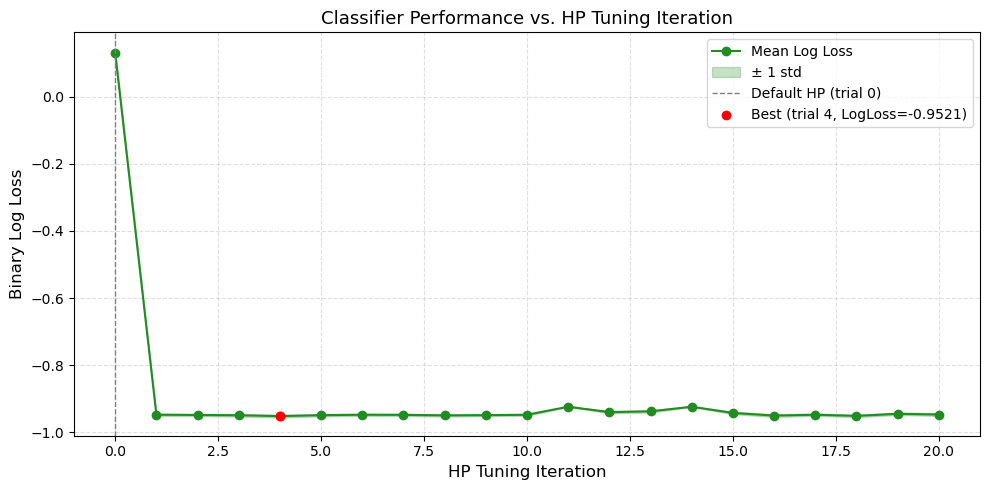

In [16]:
plot_classifier_performance(results_weighted)

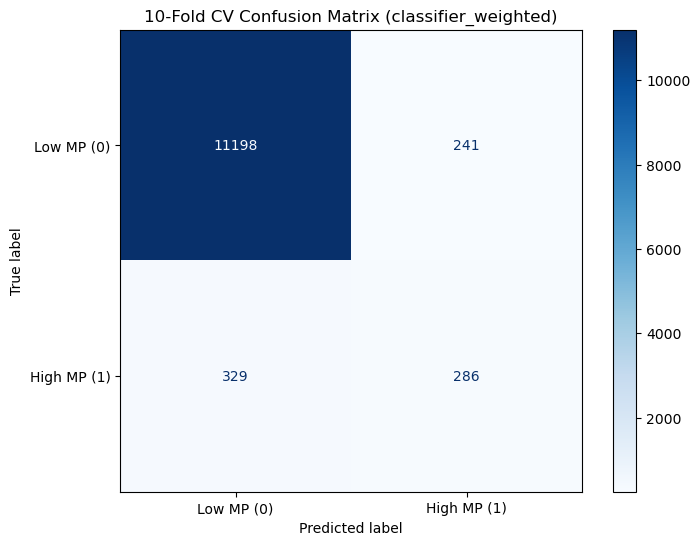

In [17]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Generate 'Out-of-Fold' predictions for the entire training set
# This uses the best hyperparameters found but ensures each prediction
# is made by a model that didn't see that specific data point during training.
X = df_binary.drop(columns=non_features)
y = df_binary[output]

y_pred_cv = cross_val_predict(model_weighted, X, y, cv=10)

# 2. Compute the matrix
cm = confusion_matrix(y, y_pred_cv)

# 3. Plot the matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low MP (0)', 'High MP (1)'])
disp.plot(cmap='Blues', ax=ax)
ax.set_title(f'10-Fold CV Confusion Matrix ({model_type})')
plt.show()

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# 1. Calculate individual metrics
accuracy  = accuracy_score(y, y_pred_cv)
precision = precision_score(y, y_pred_cv) # Focuses on 'High MP' (Class 1)
recall    = recall_score(y, y_pred_cv)    # Focuses on 'High MP' (Class 1)
f1        = f1_score(y, y_pred_cv)        # Harmonic mean of Precision/Recall

# 2. Print a clean summary
print(f"--- Performance Metrics: {model_type} Strategy ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f} (When model says 'High', how often is it right?)")
print(f"Recall:    {recall:.4f} (How many 'High' compounds did we catch?)")
print(f"F1-Score:  {f1:.4f}")
print("-" * 45)

# 3. Print the full report for both classes
print("Full Classification Report:")
print(classification_report(y, y_pred_cv, target_names=['Low MP', 'High MP']))

--- Performance Metrics: classifier_weighted Strategy ---
Accuracy:  0.9527
Precision: 0.5427 (When model says 'High', how often is it right?)
Recall:    0.4650 (How many 'High' compounds did we catch?)
F1-Score:  0.5009
---------------------------------------------
Full Classification Report:
              precision    recall  f1-score   support

      Low MP       0.97      0.98      0.98     11439
     High MP       0.54      0.47      0.50       615

    accuracy                           0.95     12054
   macro avg       0.76      0.72      0.74     12054
weighted avg       0.95      0.95      0.95     12054



TEST SET EVALUATION

In [20]:
# Binary classifier
# data = combined, same as the regression model but with the binary label?
df = pd.read_parquet("../0_data/processed_data/data_with_selected_features_LGB_All_scaled_binary.parquet")
df_test = df[df['Type'] == 'Test'].reset_index(drop=True)

df_test

,SMILES,MP,Type,MP_label,RDKit_FpDensityMorgan3,RDKit_TPSA,RDKit_NumRotatableBonds,RDKit_SMR_VSA10,RDKit_BCUT2D_LOGPHI,RDKit_BCUT2D_MRLOW,...,RDKit_Chi2n,RDKit_SlogP_VSA3,RDKit_fr_Ar_NH,RDKit_EState_VSA4,MACCS_89,RDKit_SMR_VSA9,MACCS_131,RDKit_fr_imidazole,RDKit_Chi0,Binary
0,C/C(=C\C(=N/Nc1ccc(cc1[N+](=O)[O-])[N+](=O)[O-...,115.0,Test,L,0.273579,1.654480,1.262156,0.802312,0.225087,-1.105193,...,0.667614,-0.775518,-0.20324,0.531278,-0.488331,-0.586923,-0.562084,-0.133569,1.401025,0
1,COC(=O)C(=C(SCc1ccccc1)SCc1ccccc1)C#N,104.0,Test,L,-0.835231,-0.048016,1.262156,0.846509,0.612333,-0.617962,...,0.304196,1.986153,-0.20324,0.023628,-0.488331,0.374209,-0.562084,-0.133569,0.908283,0
2,CC(=O)c1ccc(c(c1)F)O,128.0,Test,L,0.783228,-0.407457,-0.561777,-0.782647,-0.440110,-0.171672,...,-0.744034,-0.775518,-0.20324,0.107665,-0.488331,0.323579,-0.562084,-0.133569,-0.746893,0
3,NC(=O)C1=C(CCCC1)CCc1ccccc1,113.0,Test,L,0.465599,-0.244739,0.350190,-0.774131,0.168145,-0.578826,...,0.233292,0.696792,-0.20324,2.241899,-0.488331,-0.586923,-0.562084,-0.133569,-0.056709,0
4,OCCOc1ccccc1,12.0,Test,L,0.521953,-0.627787,0.046201,-1.180027,-0.902406,0.016888,...,-0.880423,-0.775518,-0.20324,-0.425651,-0.488331,0.323579,-0.562084,-0.133569,-0.972721,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5161,CN(CCNCc1cc(ccc1O)[N+](=O)[O-])C,158.5,Test,L,1.029135,0.754332,0.958167,-0.789234,-0.107671,-1.088784,...,-0.004857,0.083653,-0.20324,0.187604,-0.488331,0.323579,1.779092,-0.133569,0.084641,0
5162,C[Si](C#Cc1ccc(cc1)C#C[Si](C)(C)C)(C)C,120.0,Test,L,-2.139191,-1.455709,-0.865765,-0.070479,-0.999456,2.659783,...,1.017151,-0.775518,-0.20324,0.023628,-0.488331,3.044038,-0.562084,-0.133569,0.268670,0
5163,Brc1ccc(c(c1)C(F)(F)F)[N+](=O)[O-],34.0,Test,L,0.248235,-0.243334,-0.561777,0.305349,0.655692,-1.094674,...,-0.665594,0.035283,-0.20324,-0.399178,-0.488331,-0.586923,-0.562084,-0.133569,-0.275050,0
5164,OC(=O)C(C(=O)O)Cc1ccccc1,121.0,Test,L,-0.436059,0.640795,0.350190,-0.359698,-0.795887,-0.653368,...,-0.462402,1.326200,-0.20324,-0.906021,2.047792,-0.586923,1.779092,-0.133569,-0.346521,0


In [21]:
# 1. Prepare the test features (X_test) and actual labels (y_test)
X_test = df_test.drop(columns=non_features)
y_test = df_test[output]

# 2. Use the single "Best Model" to make predictions
y_pred_test = model_weighted.predict(X_test)

# 3. Get the probabilities (useful for confidence analysis)
y_prob_test = model_weighted.predict_proba(X_test)[:, 1]

print("Predictions completed on the test set.")

Predictions completed on the test set.


--- Performance Metrics: classifier_weighted Strategy ---
Accuracy:  0.9510
Precision: 0.5194 (When model says 'High', how often is it right?)
Recall:    0.5095 (How many 'High' compounds did we catch?)
F1-Score:  0.5144
---------------------------------------------
--- Final Test Results: classifier_weighted Strategy ---
              precision    recall  f1-score   support

      Low MP       0.97      0.97      0.97      4903
     High MP       0.52      0.51      0.51       263

    accuracy                           0.95      5166
   macro avg       0.75      0.74      0.74      5166
weighted avg       0.95      0.95      0.95      5166



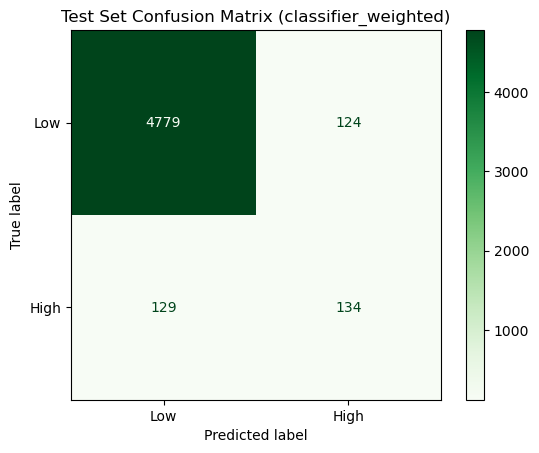

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Calculate individual metrics
accuracy  = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test) # Focuses on 'High MP' (Class 1)
recall    = recall_score(y_test, y_pred_test)    # Focuses on 'High MP' (Class 1)
f1        = f1_score(y_test, y_pred_test)        # Harmonic mean of Precision/Recall

# 2. Print a clean summary
print(f"--- Performance Metrics: {model_type} Strategy ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f} (When model says 'High', how often is it right?)")
print(f"Recall:    {recall:.4f} (How many 'High' compounds did we catch?)")
print(f"F1-Score:  {f1:.4f}")
print("-" * 45)

# 1. The Text Report
print(f"--- Final Test Results: {model_type} Strategy ---")
print(classification_report(y_test, y_pred_test, target_names=['Low MP', 'High MP']))

# 2. The Confusion Matrix
cm_test = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['Low', 'High'])
disp.plot(cmap='Greens')
plt.title(f'Test Set Confusion Matrix ({model_type})')
plt.show()